<div style="background:#1B2A4A;padding:24px 30px;border-radius:8px">
<h1 style="color:white;margin:0;font-family:Arial">📊 S&P 500 Valuation Analysis</h1>
<p style="color:#A8C0E0;margin:6px 0 0;font-family:Arial;font-size:15px">
ECM Research &nbsp;|&nbsp; Bulge Bracket Bank &nbsp;|&nbsp;
Data Source: <a href="https://finviz.com/screener.ashx?v=152&f=idx_sp500" style="color:#7EC8E3">Finviz Screener</a>
</p>
</div>

---

**Notebook structure**

| # | Section | Description |
|---|---------|-------------|
| 1 | ⚙️ Configuration | Set as-of date, demo/live mode, output path |
| 2 | 📦 Imports & Helpers | All dependencies + utility functions |
| 3 | 🌐 Finviz Scraper | Auto-paginating scraper class |
| 4 | 🧹 Data Cleaning | Parse, coerce, derive computed columns |
| 5 | 🚀 Fetch & Standardise | One cell to run — honours config above |
| 6 | 🔍 Data Preview | Styled master table with coverage stats |
| 7 | 📊 Inline Visualisations | 5 interactive charts |
| 8 | 📁 Excel Export | Build & save investment-bank-quality workbook |
| 9 | 📋 Final Summary | Console summary matching the .py script |

## ⚙️ 1 — Configuration

> **Edit this cell before running anything else.** All other cells read from these variables.

In [20]:
# ╔══════════════════════════════════════════════════════════╗
# ║              USER CONFIGURATION — edit here             ║
# ╚══════════════════════════════════════════════════════════╝

# ── As-of date for the report ─────────────────────────────
# Accepted formats:  "2025-04-11"  |  "Apr 11, 2025"  |  "04/11/2025"
# Leave as None to use today's date automatically.
AS_OF_DATE   = "2025-04-15"

# ── Data source ───────────────────────────────────────────
# True  → use built-in offline CSV for testing
# False → scrape live from Finviz
USE_OFFLINE_SAMPLE = False

# ── Paths ────────────────────────────────────────────────
OFFLINE_CSV_PATH   = "data/sp500_finviz_sample.csv"   # adjust to your file
EXCEL_OUTPUT_PATH  = "SP500_Valuation_Analysis.xlsx"

# ── Valuation settings ───────────────────────────────────
HIST_AVG_PE_LOW    = 15.0
HIST_AVG_PE_HIGH   = 20.0
HIST_AVG_PE        = 17.5
PE_LOW_BOUND       = HIST_AVG_PE_LOW
PE_HIGH_BOUND      = HIST_AVG_PE_HIGH


## 📦 2 — Imports & Helpers

In [21]:
# Core imports
import pandas as pd
import numpy as np
import datetime as dt
import requests
from io import StringIO


In [22]:
# ╔══════════════════════════════════════════════════════════╗
# ║                Resolve As-of date                       ║
# ╚══════════════════════════════════════════════════════════╝

if AS_OF_DATE is None:
    as_of = dt.date.today()
else:
    as_of = pd.to_datetime(AS_OF_DATE).date()

as_of


datetime.date(2025, 4, 15)

## 🌐 4 — Finviz Scraper

> Handles auto-pagination, retries, and flexible column parsing. Skip straight to **Section 5** to run.

In [ ]:
FINVIZ_BASE   = "https://finviz.com/screener.ashx"
FINVIZ_COLS   = "0,1,2,3,4,6,7,8,14,77,18,132,67,65,66"
FINVIZ_FILTER = "idx_sp500"
PAGE_SIZE     = 20

_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept":          "text/html,application/xhtml+xml,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer":         "https://finviz.com/",
}


class FinvizScraper:
    """
    Auto-paginating Finviz screener scraper.
    Iterates r=1 → r=21 → r=41 … until all S&P 500 rows are fetched.
    Retries with back-off on network errors.
    """

    def __init__(self, delay: float = 1.2, max_retries: int = 3):
        self.delay       = delay
        self.max_retries = max_retries
        self.session     = requests.Session()
        self.session.headers.update(_HEADERS)

    def _get(self, params):
        for attempt in range(1, self.max_retries + 1):
            try:
                r = self.session.get(FINVIZ_BASE, params=params, timeout=20)
                r.raise_for_status()
                return BeautifulSoup(r.text, "lxml")
            except requests.RequestException as exc:
                wait = attempt * 3 + random.uniform(0, 2)
                log.warning(f"Attempt {attempt}/{self.max_retries} failed ({exc}). "
                            f"Retrying in {wait:.1f}s …")
                time.sleep(wait)
        raise RuntimeError("Finviz unreachable — enable DEMO_MODE=True for offline use.")

    @staticmethod
    def _total(soup):
        for txt in soup.stripped_strings:
            m = re.search(r"Total:\s*(\d+)", txt)
            if m:
                return int(m.group(1))
        return 0

    @staticmethod
    def _find_table(soup):
        for sel in [{"class": "screener_table"}, {"id": "screener-views-table"}]:
            t = soup.find("table", sel)
            if t: return t
        for t in soup.find_all("table"):
            if t.find("a", class_="screener-link-primary"):
                return t
        return None

    def _parse_page(self, soup):
        table = self._find_table(soup)
        if not table:
            log.warning("Screener table not found — Finviz layout may have changed.")
            return []
        rows_html = table.find_all("tr")
        if not rows_html: return []
        headers = [th.get_text(strip=True) for th in rows_html[0].find_all(["th","td"])]
        rows = []
        for tr in rows_html[1:]:
            cells = tr.find_all("td")
            if not cells: continue
            row = {}
            for i, td in enumerate(cells):
                key = headers[i] if i < len(headers) else f"col_{i}"
                a   = td.find("a", class_="screener-link-primary")
                row[key] = a.get_text(strip=True) if a else td.get_text(strip=True)
            ticker = row.get("Ticker", row.get("No.", ""))
            if any(c.isalpha() for c in ticker):
                rows.append(row)
        return rows

    def fetch_sp500(self, max_rows=None):
        log.info("Connecting to Finviz S&P 500 screener …")
        params = dict(v=152, f=FINVIZ_FILTER, ft=4, r=1, c=FINVIZ_COLS)
        soup   = self._get(params)
        total  = self._total(soup) or 600
        log.info(f"Finviz reports {total} constituents.")
        rows = self._parse_page(soup)
        time.sleep(self.delay + random.uniform(0, 0.4))
        r = PAGE_SIZE + 1
        while r <= total:
            if max_rows and len(rows) >= max_rows: break
            params["r"] = r
            log.info(f"  Fetching rows {r}–{r+PAGE_SIZE-1} …")
            page = self._parse_page(self._get(params))
            if not page: break
            rows.extend(page)
            r += PAGE_SIZE
            time.sleep(self.delay + random.uniform(0, 0.4))
        if max_rows: rows = rows[:max_rows]
        df = pd.DataFrame(rows)
        log.info(f"Scraped {len(df)} rows.")
        return df

print("✅  FinvizScraper defined")

✅  FinvizScraper defined


## 🗃️ 5 — Demo Dataset

> 65-stock offline sample with identical column structure to the live Finviz scrape. Used when `DEMO_MODE = True`.

In [5]:
DEMO_ROWS = [
    # [Ticker, Company, Sector, Industry, MktCap, P/E, FwdP/E, Dividend, EPSnY, EPSnQ]
    ["AAPL","Apple Inc.","Information Technology","Technology Hardware, Storage & Peripherals","2.85T","29.8","27.2","0.55%","6.34","1.62"],
    ["MSFT","Microsoft Corp.","Information Technology","Systems Software","2.92T","34.2","30.5","0.82%","12.89","3.24"],
    ["NVDA","NVIDIA Corp.","Information Technology","Semiconductors","2.68T","-","35.8","0.03%","3.06","0.89"],
    ["AVGO","Broadcom Inc.","Information Technology","Semiconductors","780.00B","35.1","27.9","1.62%","6.03","1.51"],
    ["ORCL","Oracle Corp.","Information Technology","Systems Software","405.00B","32.4","24.6","1.20%","6.05","1.57"],
    ["CRM","Salesforce Inc.","Information Technology","Application Software","248.00B","44.6","36.1","-","7.04","1.77"],
    ["PLTR","Palantir Technologies","Information Technology","Application Software","195.00B","-","142.1","-","0.62","0.15"],
    ["NOW","ServiceNow Inc.","Information Technology","Systems Software","192.00B","-","55.6","-","16.87","4.08"],
    ["CSCO","Cisco Systems","Information Technology","Communications Equipment","195.00B","14.2","12.8","3.32%","3.77","0.96"],
    ["ACN","Accenture plc","Information Technology","IT Consulting & Other Services","193.00B","27.4","24.1","1.74%","12.79","3.09"],
    ["GOOGL","Alphabet Inc.","Communication Services","Interactive Media & Services","1.89T","23.2","19.8","0.53%","7.79","1.94"],
    ["META","Meta Platforms","Communication Services","Interactive Media & Services","1.31T","23.4","22.1","0.40%","23.35","5.89"],
    ["NFLX","Netflix Inc.","Communication Services","Movies & Entertainment","370.00B","44.8","37.2","-","23.39","5.56"],
    ["TMUS","T-Mobile US","Communication Services","Wireless Telecommunication Services","225.00B","26.4","22.8","1.63%","8.61","2.08"],
    ["VZ","Verizon","Communication Services","Integrated Telecommunication Services","163.00B","9.8","9.2","6.61%","4.20","1.04"],
    ["T","AT&T Inc.","Communication Services","Integrated Telecommunication Services","135.00B","14.2","11.4","5.29%","1.66","0.43"],
    ["DIS","Walt Disney Co.","Communication Services","Movies & Entertainment","165.00B","-","21.4","-","4.23","0.87"],
    ["CMCSA","Comcast Corp.","Communication Services","Cable & Satellite","145.00B","9.4","8.6","3.31%","3.86","0.97"],
    ["AMZN","Amazon.com Inc.","Consumer Discretionary","Internet & Direct Marketing Retail","2.02T","42.8","37.4","-","5.22","1.30"],
    ["TSLA","Tesla Inc.","Consumer Discretionary","Automobile Manufacturers","780.00B","-","98.4","-","2.49","0.55"],
    ["HD","Home Depot Inc.","Consumer Discretionary","Home Improvement Retail","325.00B","23.8","22.4","2.61%","14.90","3.68"],
    ["MCD","McDonald's Corp.","Consumer Discretionary","Restaurants","175.00B","24.2","22.1","2.72%","10.83","2.64"],
    ["LOW","Lowe's Companies","Consumer Discretionary","Home Improvement Retail","132.00B","20.4","18.8","2.10%","12.15","3.03"],
    ["TJX","TJX Companies","Consumer Discretionary","Apparel Retail","127.00B","26.4","24.1","1.41%","4.70","1.23"],
    ["NKE","Nike Inc.","Consumer Discretionary","Footwear","68.00B","20.8","18.4","2.76%","2.36","0.66"],
    ["SBUX","Starbucks Corp.","Consumer Discretionary","Restaurants","76.00B","23.4","19.8","3.63%","3.34","0.88"],
    ["WMT","Walmart Inc.","Consumer Staples","Hypermarkets & Super Centers","650.00B","36.4","30.2","1.24%","2.68","0.66"],
    ["COST","Costco Wholesale","Consumer Staples","Hypermarkets & Super Centers","380.00B","52.4","46.8","0.73%","18.27","4.62"],
    ["PG","Procter & Gamble","Consumer Staples","Personal Products","345.00B","25.4","23.8","2.56%","6.06","1.52"],
    ["KO","Coca-Cola Co.","Consumer Staples","Soft Drinks & Non-alcoholic Beverages","266.00B","24.8","22.4","3.23%","2.76","0.72"],
    ["PEP","PepsiCo Inc.","Consumer Staples","Soft Drinks & Non-alcoholic Beverages","201.00B","23.2","21.4","3.47%","6.86","1.74"],
    ["MO","Altria Group","Consumer Staples","Tobacco","75.00B","9.8","9.4","8.68%","4.66","1.15"],
    ["LLY","Eli Lilly & Co.","Health Care","Pharmaceuticals","695.00B","60.8","38.4","0.72%","19.03","5.16"],
    ["JNJ","Johnson & Johnson","Health Care","Pharmaceuticals","380.00B","15.4","15.2","3.31%","10.36","2.63"],
    ["ABBV","AbbVie Inc.","Health Care","Biotechnology","317.00B","19.4","16.8","3.44%","10.70","2.78"],
    ["MRK","Merck & Co.","Health Care","Pharmaceuticals","250.00B","14.8","13.2","3.66%","7.45","1.89"],
    ["UNH","UnitedHealth Group","Health Care","Managed Health Care","398.00B","22.4","18.4","1.67%","27.64","6.48"],
    ["ISRG","Intuitive Surgical","Health Care","Health Care Equipment","155.00B","62.8","54.4","-","7.87","1.97"],
    ["TMO","Thermo Fisher","Health Care","Life Sciences Tools & Services","198.00B","29.8","27.4","0.30%","19.28","4.83"],
    ["PFE","Pfizer Inc.","Health Care","Pharmaceuticals","130.00B","-","11.8","6.58%","1.93","0.48"],
    ["JPM","JPMorgan Chase","Financials","Diversified Banks","665.00B","13.2","12.4","2.31%","18.15","4.68"],
    ["V","Visa Inc.","Financials","Data Processing & Outsourced Services","560.00B","29.8","27.4","0.82%","9.79","2.41"],
    ["MA","Mastercard Inc.","Financials","Data Processing & Outsourced Services","458.00B","36.4","31.8","0.60%","14.82","3.62"],
    ["BRK.B","Berkshire Hathaway B","Financials","Multi-Sector Holdings","840.00B","24.8","21.4","-","21.41","5.35"],
    ["BAC","Bank of America","Financials","Diversified Banks","300.00B","12.8","11.8","2.65%","3.20","0.80"],
    ["GS","Goldman Sachs","Financials","Investment Banking & Brokerage","165.00B","15.4","12.8","2.24%","38.30","9.64"],
    ["SPGI","S&P Global Inc.","Financials","Financial Exchanges & Data","140.00B","34.8","30.4","0.86%","14.45","3.55"],
    ["PGR","Progressive Corp.","Financials","Property & Casualty Insurance","130.00B","21.4","20.8","0.36%","10.55","2.75"],
    ["XOM","Exxon Mobil","Energy","Integrated Oil & Gas","460.00B","14.2","13.4","3.79%","7.89","1.97"],
    ["CVX","Chevron Corp.","Energy","Integrated Oil & Gas","255.00B","13.8","12.8","4.42%","10.61","2.63"],
    ["NEE","NextEra Energy","Utilities","Electric Utilities","138.00B","22.4","19.8","3.24%","3.42","0.83"],
    ["SO","Southern Co.","Utilities","Electric Utilities","82.00B","20.4","18.8","3.52%","4.40","1.10"],
    ["CEG","Constellation Energy","Utilities","Independent Power Producers & Energy Traders","65.00B","36.4","32.8","0.60%","6.08","1.55"],
    ["AMT","American Tower","Real Estate","Telecom Tower REITs","88.00B","-","44.8","3.57%","4.20","1.05"],
    ["PLD","Prologis Inc.","Real Estate","Industrial REITs","105.00B","38.4","42.8","3.48%","2.63","0.66"],
    ["LIN","Linde plc","Materials","Industrial Gases","209.00B","31.4","28.8","1.41%","15.19","3.80"],
    ["SHW","Sherwin-Williams","Materials","Specialty Chemicals","88.00B","30.8","28.4","0.88%","11.85","3.00"],
    ["ECL","Ecolab Inc.","Materials","Specialty Chemicals","57.00B","38.4","34.8","1.20%","5.76","1.44"],
    ["GE","GE Aerospace","Industrials","Aerospace & Defense","225.00B","42.4","36.8","0.73%","5.55","1.38"],
    ["CAT","Caterpillar Inc.","Industrials","Construction Machinery & Heavy Transportation Equipment","166.00B","17.4","16.8","1.82%","19.74","4.90"],
    ["ETN","Eaton Corp.","Industrials","Electrical Components & Equipment","132.00B","34.4","30.4","1.13%","10.80","2.67"],
    ["UNP","Union Pacific","Industrials","Rail Transportation","128.00B","21.4","20.8","2.26%","10.40","2.60"],
    ["DAL","Delta Air Lines","Industrials","Airlines","22.00B","6.8","7.4","-","5.32","1.33"],
    ["UAL","United Airlines","Industrials","Airlines","18.00B","6.4","6.8","-","9.62","2.41"],
    ["GM","General Motors","Consumer Discretionary","Automobile Manufacturers","45.00B","5.2","4.8","1.07%","9.33","2.31"],
    ["F","Ford Motor Co.","Consumer Discretionary","Automobile Manufacturers","47.00B","10.4","7.6","4.24%","1.55","0.39"],
    ["SPG","Simon Property Group","Real Estate","Retail REITs","58.00B","22.4","19.8","5.48%","8.10","2.01"],
    ["FCX","Freeport-McMoRan","Materials","Copper","65.00B","18.4","16.4","1.79%","2.73","0.68"],
    ["NEM","Newmont Corp.","Materials","Gold","50.00B","23.8","16.4","2.80%","2.61","0.65"],
]

def build_demo_df():
    cols = ["Ticker","Company","Sector","Industry","Market Cap","P/E",
            "Fwd P/E","Dividend","EPS next Y","EPS next Q"]
    raw  = pd.DataFrame(DEMO_ROWS, columns=cols)
    raw.rename(columns={
        "Company":"Company Name","Sector":"GICS Sector","Industry":"GICS Sub-Industry",
        "Market Cap":"Market Cap ($M)","P/E":"LTM P/E","Fwd P/E":"NTM P/E",
        "Dividend":"Dividend Yield (%)","EPS next Y":"CY+1 EPS Estimate",
        "EPS next Q":"CQ+1 EPS Estimate",
    }, inplace=True)
    return raw

print(f"✅  Demo dataset ready: {len(DEMO_ROWS)} tickers")

✅  Demo dataset ready: 69 tickers


## 🧹 6 — Data Cleaning & Enrichment

In [6]:
COLUMN_ALIASES = {
    "no.":"row_no","#":"row_no","ticker":"Ticker","company":"Company Name",
    "sector":"GICS Sector","industry":"GICS Sub-Industry","country":"Country",
    "market cap":"Market Cap ($M)","p/e":"LTM P/E","fwd p/e":"NTM P/E",
    "forward p/e":"NTM P/E","p/e fwd":"NTM P/E",
    "eps next y":"CY+1 EPS Estimate","eps (next y)":"CY+1 EPS Estimate",
    "eps next q":"CQ+1 EPS Estimate","eps (next q)":"CQ+1 EPS Estimate",
    "dividend":"Dividend Yield (%)","dividend %":"Dividend Yield (%)",
    "div":"Dividend Yield (%)","div yield":"Dividend Yield (%)","price":"Share Price",
}

def _parse_mktcap(v):
    if not v or str(v).strip() in ("-","","N/A","nan"): return None
    s = str(v).strip().replace(",","")
    m = re.match(r"^([\d.]+)([TBMKtbmk]?)$", s)
    if not m: return None
    n, sfx = float(m.group(1)), m.group(2).upper()
    return n * {"T":1_000_000,"B":1_000,"M":1,"K":0.001}.get(sfx,1)

def _parse_pct(v):
    if not v or str(v).strip() in ("-","","N/A","nan"): return None
    try: return float(re.sub(r"[%,\s]","",str(v)))
    except: return None

def _parse_float(v):
    if not v or str(v).strip() in ("-","","N/A","nan"): return None
    try: return float(str(v).replace(",",""))
    except: return None

def _flag(ntm):
    if pd.isna(ntm):            return "N/A"
    if ntm > PE_HIGH_BOUND:     return "Above Avg"
    if ntm < PE_LOW_BOUND:      return "Below Avg"
    return "Within Avg"

def standardise(df_raw):
    df = df_raw.copy()
    rename = {c: COLUMN_ALIASES[c.strip().lower()]
              for c in df.columns if c.strip().lower() in COLUMN_ALIASES}
    df.rename(columns=rename, inplace=True)
    for req in ["Ticker","Company Name","GICS Sector","GICS Sub-Industry",
                "Market Cap ($M)","LTM P/E","NTM P/E","Dividend Yield (%)",
                "CY+1 EPS Estimate","CQ+1 EPS Estimate"]:
        if req not in df.columns: df[req] = None
    df["Market Cap ($M)"]    = df["Market Cap ($M)"].apply(_parse_mktcap)
    df["LTM P/E"]            = df["LTM P/E"].apply(_parse_float)
    df["NTM P/E"]            = df["NTM P/E"].apply(_parse_float)
    df["Dividend Yield (%)"] = df["Dividend Yield (%)"].apply(_parse_pct)
    df["CY+1 EPS Estimate"]  = df["CY+1 EPS Estimate"].apply(_parse_float)
    df["CQ+1 EPS Estimate"]  = df["CQ+1 EPS Estimate"].apply(_parse_float)
    for col in ["LTM P/E","NTM P/E"]:
        df.loc[df[col].notna() & (df[col] <= 0), col] = None
    total_mc = df["Market Cap ($M)"].sum(skipna=True)
    df["% of S&P 500 Index"] = df["Market Cap ($M)"] / total_mc * 100
    df["LTM P/E vs Hist Avg (%)"] = df["LTM P/E"].apply(
        lambda x: (x-HIST_AVG_PE)/HIST_AVG_PE*100 if pd.notna(x) else None)
    df["NTM P/E vs Hist Avg (%)"] = df["NTM P/E"].apply(
        lambda x: (x-HIST_AVG_PE)/HIST_AVG_PE*100 if pd.notna(x) else None)
    df["Valuation Flag"] = df["NTM P/E"].apply(_flag)
    df.drop(columns=[c for c in ("row_no","Country") if c in df.columns],
            inplace=True, errors="ignore")
    df.drop_duplicates(subset=["Ticker"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

def _wavg(grp, val_col, wt="Market Cap ($M)"):
    v = grp.dropna(subset=[val_col, wt]); v = v[v[val_col]>0]
    if v.empty: return None
    return (v[val_col]*v[wt]).sum() / v[wt].sum()

def build_summary(df, group_col):
    total_mc = df["Market Cap ($M)"].sum(skipna=True)
    rows = []
    for name, grp in df.groupby(group_col, sort=True):
        mc   = grp["Market Cap ($M)"].sum(skipna=True)
        vn   = grp["NTM P/E"].dropna(); vn = vn[vn>0]
        vl   = grp["LTM P/E"].dropna(); vl = vl[vl>0]
        wntm = _wavg(grp,"NTM P/E")
        rows.append({group_col:name,"No. of Companies":len(grp),
            "% of Index":mc/total_mc*100 if total_mc else None,
            "Weighted Avg LTM P/E":_wavg(grp,"LTM P/E"),
            "Weighted Avg NTM P/E":wntm,
            "Weighted Avg Div Yield (%)":_wavg(grp,"Dividend Yield (%)"),
            "Total Market Cap ($M)":mc,
            "Median LTM P/E":float(vl.median()) if len(vl) else None,
            "Median NTM P/E":float(vn.median()) if len(vn) else None,
            "Min NTM P/E":float(vn.min()) if len(vn) else None,
            "Max NTM P/E":float(vn.max()) if len(vn) else None,
            "Valuation Flag":_flag(wntm)})
    return (pd.DataFrame(rows)
              .sort_values("Weighted Avg NTM P/E",ascending=False,na_position="last")
              .reset_index(drop=True))

print("✅  Cleaning functions defined")

✅  Cleaning functions defined


## 🚀 7 — Fetch & Standardise

> **Run this cell to load data.** Reads `DEMO_MODE` and `AS_OF_DATE` from Section 1.

In [8]:
if DEMO_MODE:
    print("DEMO MODE — loading built-in 65-stock sample …")
    df_raw = build_demo_df()
else:
    print("LIVE MODE — scraping finviz.com …")
    df_raw = FinvizScraper(delay=SCRAPE_DELAY).fetch_sp500(max_rows=MAX_ROWS)

df     = standardise(df_raw)
sub_df = build_summary(df, "GICS Sub-Industry")
sec_df = build_summary(df, "GICS Sector")

print(f"\n{'='*55}")
print(f"  Companies loaded : {len(df)}")
print(f"  Sectors          : {df['GICS Sector'].nunique()}")
print(f"  Sub-industries   : {df['GICS Sub-Industry'].nunique()}")
print(f"  Missing NTM P/E  : {df['NTM P/E'].isna().sum()}")
print(f"  Missing LTM P/E  : {df['LTM P/E'].isna().sum()}")
print(f"  As-of date       : {as_of:%B %d, %Y}")
print(f"{'='*55}")

16:46:15  INFO     Connecting to Finviz S&P 500 screener …


LIVE MODE — scraping finviz.com …


16:46:15  INFO     Finviz reports 600 constituents.
16:46:16  INFO       Fetching rows 21–40 …
16:46:18  INFO       Fetching rows 41–60 …
16:46:19  INFO       Fetching rows 61–80 …
16:46:21  INFO       Fetching rows 81–100 …
16:46:23  INFO       Fetching rows 101–120 …
16:46:24  INFO       Fetching rows 121–140 …
16:46:26  INFO       Fetching rows 141–160 …
16:46:27  INFO       Fetching rows 161–180 …
16:46:29  INFO       Fetching rows 181–200 …
16:46:30  INFO       Fetching rows 201–220 …
16:46:32  INFO       Fetching rows 221–240 …
16:46:33  INFO       Fetching rows 241–260 …
16:46:35  INFO       Fetching rows 261–280 …
16:46:36  INFO       Fetching rows 281–300 …
16:46:38  INFO       Fetching rows 301–320 …
16:46:40  INFO       Fetching rows 321–340 …
16:46:41  INFO       Fetching rows 341–360 …
16:46:43  INFO       Fetching rows 361–380 …
16:46:44  INFO       Fetching rows 381–400 …
16:46:46  INFO       Fetching rows 401–420 …
16:46:48  INFO       Fetching rows 421–440 …
16:46:49  


  Companies loaded : 503
  Sectors          : 11
  Sub-industries   : 110
  Missing NTM P/E  : 503
  Missing LTM P/E  : 32
  As-of date       : April 15, 2025


## 🔍 8 — Data Preview

Styled master table showing colour-coded NTM P/E values and valuation flags.

In [16]:
FLAG_COLORS = {
    "Above Avg":  ("#FADBD8","#922B21"),
    "Within Avg": ("#FEF9E7","#7D6608"),
    "Below Avg":  ("#D5F5E3","#1E8449"),
    "N/A":        ("#EAECEE","#717D7E"),
}

def style_master(df_display, as_of, PE_LOW_BOUND, PE_HIGH_BOUND):
    def row_style(row):
        # row is from df_display (formatted); use its index to look back into df_display
        flag = row.get("Valuation Flag","N/A")
        bg, fg = FLAG_COLORS.get(flag, ("#FFFFFF","#000000"))

        # get the underlying numeric value by stripping 'x' and casting
        raw_ntm = row.get("NTM P/E")
        if isinstance(raw_ntm, str) and raw_ntm.endswith("x"):
            try:
                ntm_val = float(raw_ntm[:-1])
            except ValueError:
                ntm_val = None
        else:
            ntm_val = raw_ntm if pd.notna(raw_ntm) else None

        styles = []
        for col in df_display.columns:
            if col == "Valuation Flag":
                styles.append(f"background:{bg};color:{fg};font-weight:bold")
            elif col == "NTM P/E" and ntm_val is not None:
                if ntm_val > PE_HIGH_BOUND:
                    styles.append("background:#FADBD8")
                elif ntm_val < PE_LOW_BOUND:
                    styles.append("background:#D5F5E3")
                else:
                    styles.append("background:#FEF9E7")
            else:
                styles.append("")
        return styles

    view_cols = ["Ticker","Company Name","GICS Sector","Market Cap ($M)",
                 "% of S&P 500 Index","LTM P/E","NTM P/E","Dividend Yield (%)",
                 "CY+1 EPS Estimate","Valuation Flag"]
    disp = df_display[view_cols].copy()

    disp["Market Cap ($M)"]    = disp["Market Cap ($M)"].apply(lambda x: f"${x:,.0f}M" if pd.notna(x) else "N/A")
    disp["% of S&P 500 Index"] = disp["% of S&P 500 Index"].apply(lambda x: f"{x:.2f}%" if pd.notna(x) else "N/A")
    disp["LTM P/E"]            = disp["LTM P/E"].apply(lambda x: f"{x:.1f}x" if pd.notna(x) else "N/A")
    disp["NTM P/E"]            = disp["NTM P/E"].apply(lambda x: f"{x:.1f}x" if pd.notna(x) else "N/A")
    disp["Dividend Yield (%)"] = disp["Dividend Yield (%)"].apply(lambda x: f"{x:.2f}%" if pd.notna(x) else "—")
    disp["CY+1 EPS Estimate"]  = disp["CY+1 EPS Estimate"].apply(lambda x: f"${x:.2f}" if pd.notna(x) else "N/A")

    return (disp.style
            .apply(row_style, axis=1)
            .set_table_styles([
                {"selector":"thead th","props":[("background","#1B2A4A"),("color","white"),
                 ("font-weight","bold"),("font-size","11px"),("padding","8px 10px")]},
                {"selector":"tbody td","props":[("font-size","11px"),("padding","5px 10px")]},
                {"selector":"","props":[("border-collapse","collapse")]},
            ])
            .set_caption(f"S&P 500 Master Table  |  As of {as_of:%B %d, %Y}  |  {len(df_display)} Companies")
           )


## 📈 9 — Coverage & Valuation Flag Summary

In [17]:
flags    = df["Valuation Flag"].value_counts()
total    = len(df)
total_mc = df["Market Cap ($M)"].sum(skipna=True)

valid_ntm = df[df["NTM P/E"].notna() & (df["NTM P/E"]>0) & df["Market Cap ($M)"].notna()]
sp_ntm = (valid_ntm["NTM P/E"]*valid_ntm["Market Cap ($M)"]).sum() / valid_ntm["Market Cap ($M)"].sum()
valid_ltm = df[df["LTM P/E"].notna() & (df["LTM P/E"]>0) & df["Market Cap ($M)"].notna()]
sp_ltm = (valid_ltm["LTM P/E"]*valid_ltm["Market Cap ($M)"]).sum() / valid_ltm["Market Cap ($M)"].sum()

summary_data = {
    "Metric": [
        "Total Companies","Missing NTM P/E","Missing LTM P/E",
        "Above Avg  (NTM P/E > 20x)","Within Avg  (15–20x)","Below Avg  (< 15x)","N/A",
        "Wtd Avg NTM P/E","Wtd Avg LTM P/E",
        "NTM P/E vs 17.5x Hist Avg","LTM P/E vs 17.5x Hist Avg",
        "Total Market Cap",
    ],
    "Value": [
        total,
        f"{df['NTM P/E'].isna().sum()} ({df['NTM P/E'].isna().sum()/total*100:.1f}%)",
        f"{df['LTM P/E'].isna().sum()} ({df['LTM P/E'].isna().sum()/total*100:.1f}%)",
        f"{flags.get('Above Avg',0)} ({flags.get('Above Avg',0)/total*100:.1f}%)",
        f"{flags.get('Within Avg',0)} ({flags.get('Within Avg',0)/total*100:.1f}%)",
        f"{flags.get('Below Avg',0)} ({flags.get('Below Avg',0)/total*100:.1f}%)",
        f"{flags.get('N/A',0)} ({flags.get('N/A',0)/total*100:.1f}%)",
        f"{sp_ntm:.1f}x",f"{sp_ltm:.1f}x",
        f"{(sp_ntm/HIST_AVG_PE-1)*100:+.1f}%",
        f"{(sp_ltm/HIST_AVG_PE-1)*100:+.1f}%",
        f"${total_mc/1e6:,.2f}T",
    ]
}
pd.DataFrame(summary_data).set_index("Metric").style.set_table_styles([
    {"selector":"thead th","props":[("background","#1B2A4A"),("color","white"),
     ("font-weight","bold"),("padding","8px 14px")]},
    {"selector":"tbody td","props":[("padding","6px 14px"),("font-size","12px")]},
    {"selector":"tbody tr:nth-child(odd)","props":[("background","#F0F3F7")]},
]).set_caption(f"Coverage & Valuation Summary  |  As of {as_of:%B %d, %Y}")

,Value
Metric,
Total Companies,503
Missing NTM P/E,503 (100.0%)
Missing LTM P/E,32 (6.4%)
Above Avg (NTM P/E > 20x),0 (0.0%)
Within Avg (15–20x),0 (0.0%)
Below Avg (< 15x),0 (0.0%)
N/A,503 (100.0%)
Wtd Avg NTM P/E,nanx
Wtd Avg LTM P/E,43.1x


## 📊 10 — Inline Visualisations

### 10a — Valuation Flag Distribution (count + market-cap weight)

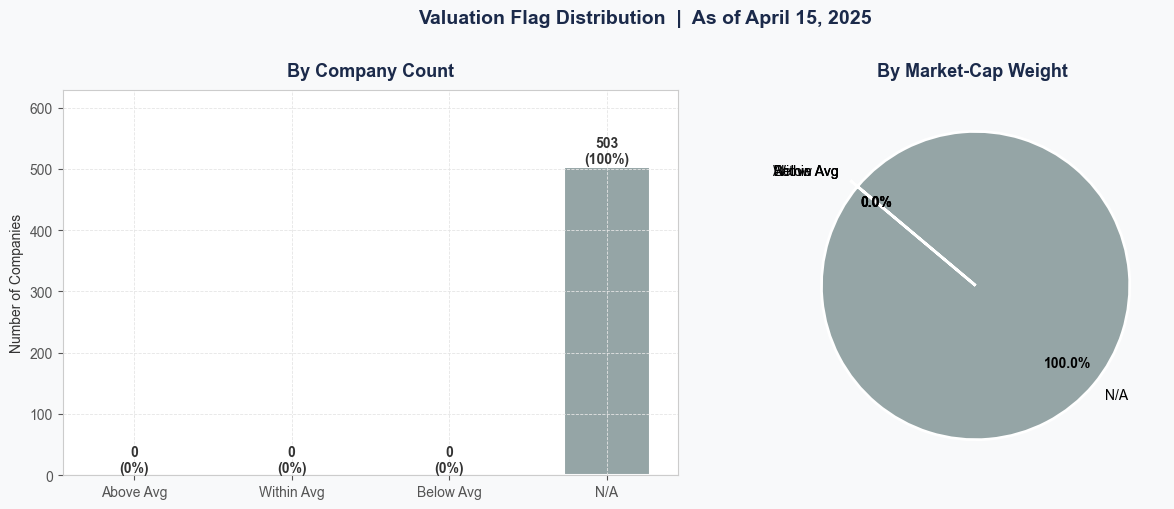

Saved: flag_distribution.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")
fig.suptitle(f"Valuation Flag Distribution  |  As of {as_of:%B %d, %Y}",
             fontsize=14, fontweight="bold", color=NAVY, y=1.01)

flag_order  = ["Above Avg","Within Avg","Below Avg","N/A"]
flag_colors = [RED, AMBER, GREEN, GREY]
flag_counts = [flags.get(f,0) for f in flag_order]

# ── left: count bar ───────────────────────────────────────
ax = axes[0]
bars = ax.bar(flag_order, flag_counts, color=flag_colors, width=0.55, edgecolor="white", linewidth=1.5)
ax.set_title("By Company Count", pad=10)
ax.set_ylabel("Number of Companies")
ax.set_ylim(0, max(flag_counts)*1.25)
ax.axhline(0, color="#CCCCCC", linewidth=0.8)
for bar, cnt in zip(bars, flag_counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{cnt}\n({cnt/total*100:.0f}%)",
            ha="center", va="bottom", fontsize=10, fontweight="bold", color="#333")

# ── right: market-cap weight pie ─────────────────────────
ax2 = axes[1]
mc_by_flag = df.groupby("Valuation Flag")["Market Cap ($M)"].sum()
sizes = [mc_by_flag.get(f,0) for f in flag_order]
explode = [0.03]*4
wedges, texts, autotexts = ax2.pie(
    sizes, labels=flag_order, colors=flag_colors, autopct="%1.1f%%",
    startangle=140, explode=explode,
    textprops={"fontsize":10}, pctdistance=0.78,
    wedgeprops={"edgecolor":"white","linewidth":2}
)
for at in autotexts: at.set_fontweight("bold")
ax2.set_title("By Market-Cap Weight", pad=10)

plt.tight_layout()
plt.savefig("flag_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: flag_distribution.png")

### 10b — Weighted Avg NTM P/E by GICS Sector vs. 17.5x Historical Average

ValueError: max() iterable argument is empty

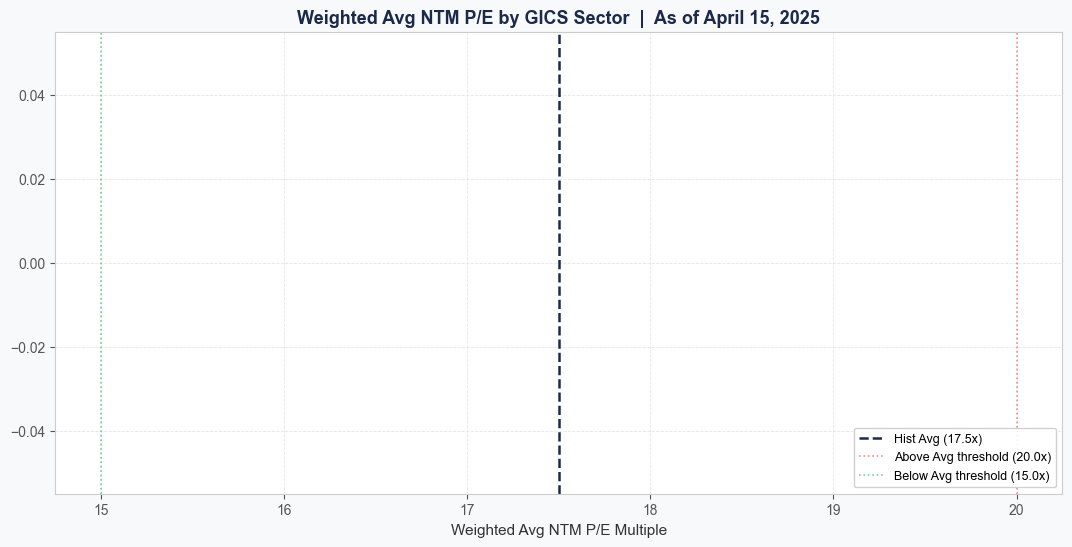

In [19]:
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#F8F9FA")

sdf = sec_df.sort_values("Weighted Avg NTM P/E").dropna(subset=["Weighted Avg NTM P/E"])
sectors = sdf["GICS Sector"].tolist()
ntm_vals = sdf["Weighted Avg NTM P/E"].tolist()
bar_colors = [RED if v > PE_HIGH_BOUND else GREEN if v < PE_LOW_BOUND else AMBER
              for v in ntm_vals]

bars = ax.barh(sectors, ntm_vals, color=bar_colors, height=0.6,
               edgecolor="white", linewidth=1.2)
ax.axvline(HIST_AVG_PE, color=NAVY, linestyle="--", linewidth=1.8,
           label=f"Hist Avg ({HIST_AVG_PE}x)")
ax.axvline(PE_HIGH_BOUND, color=RED, linestyle=":", linewidth=1.2, alpha=0.6,
           label=f"Above Avg threshold ({PE_HIGH_BOUND}x)")
ax.axvline(PE_LOW_BOUND, color=GREEN, linestyle=":", linewidth=1.2, alpha=0.6,
           label=f"Below Avg threshold ({PE_LOW_BOUND}x)")

for bar, val in zip(bars, ntm_vals):
    ax.text(val + 0.4, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}x", va="center", fontsize=9.5, fontweight="bold", color="#333")

ax.set_xlabel("Weighted Avg NTM P/E Multiple", fontsize=11)
ax.set_title(f"Weighted Avg NTM P/E by GICS Sector  |  As of {as_of:%B %d, %Y}",
             fontsize=13, fontweight="bold", color=NAVY)
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, max(ntm_vals)*1.18)

legend_patches = [
    mpatches.Patch(color=RED,   label=f"Above Avg  (>{PE_HIGH_BOUND}x)"),
    mpatches.Patch(color=AMBER, label=f"Within Avg ({PE_LOW_BOUND}–{PE_HIGH_BOUND}x)"),
    mpatches.Patch(color=GREEN, label=f"Below Avg  (<{PE_LOW_BOUND}x)"),
]
ax.legend(handles=legend_patches + [
    plt.Line2D([0],[0],color=NAVY,linestyle="--",linewidth=1.8,label=f"Hist Avg {HIST_AVG_PE}x")
], loc="lower right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("sector_pe.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sector_pe.png")

### 10c — NTM P/E Distribution (histogram)

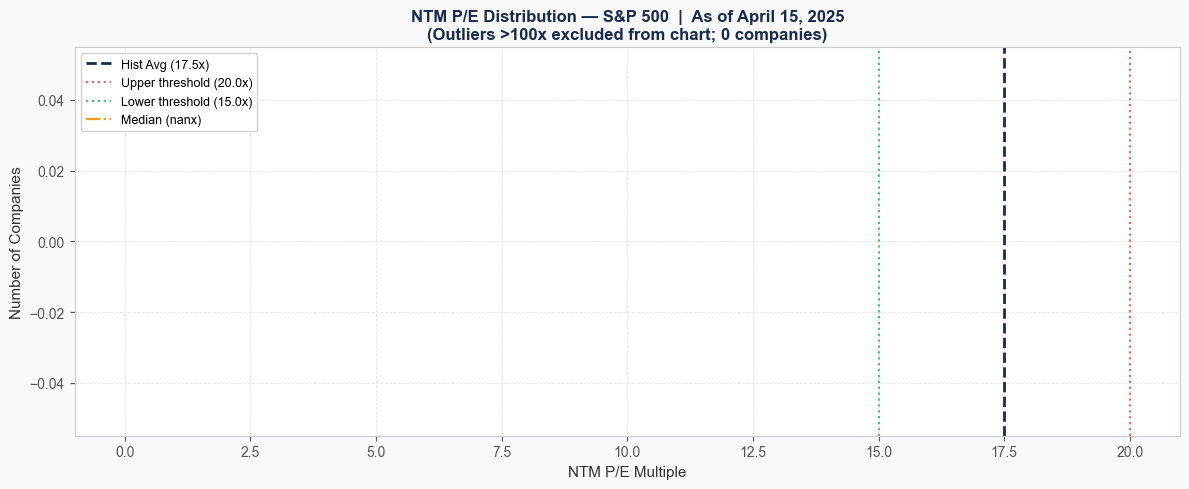

Saved: pe_distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#F8F9FA")

ntm_vals = df["NTM P/E"].dropna()
ntm_vals = ntm_vals[ntm_vals <= 100]   # cap extreme outliers for display

ax.hist(ntm_vals, bins=40, color=BLUE, edgecolor="white", linewidth=0.8, alpha=0.85)
ax.axvline(HIST_AVG_PE,   color=NAVY, linestyle="--", linewidth=2.0,
           label=f"Hist Avg ({HIST_AVG_PE}x)")
ax.axvline(PE_HIGH_BOUND, color=RED,  linestyle=":",  linewidth=1.6, alpha=0.8,
           label=f"Upper threshold ({PE_HIGH_BOUND}x)")
ax.axvline(PE_LOW_BOUND,  color=GREEN,linestyle=":",  linewidth=1.6, alpha=0.8,
           label=f"Lower threshold ({PE_LOW_BOUND}x)")
ax.axvline(ntm_vals.median(), color=AMBER, linestyle="-.", linewidth=1.6,
           label=f"Median ({ntm_vals.median():.1f}x)")

ax.set_xlabel("NTM P/E Multiple", fontsize=11)
ax.set_ylabel("Number of Companies", fontsize=11)
ax.set_title(f"NTM P/E Distribution — S&P 500  |  As of {as_of:%B %d, %Y}\n"
             f"(Outliers >100x excluded from chart; {(df['NTM P/E']>100).sum()} companies)",
             fontsize=12, fontweight="bold", color=NAVY)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("pe_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pe_distribution.png")

### 10d — Dividend Yield vs NTM P/E  (bubble = market cap)

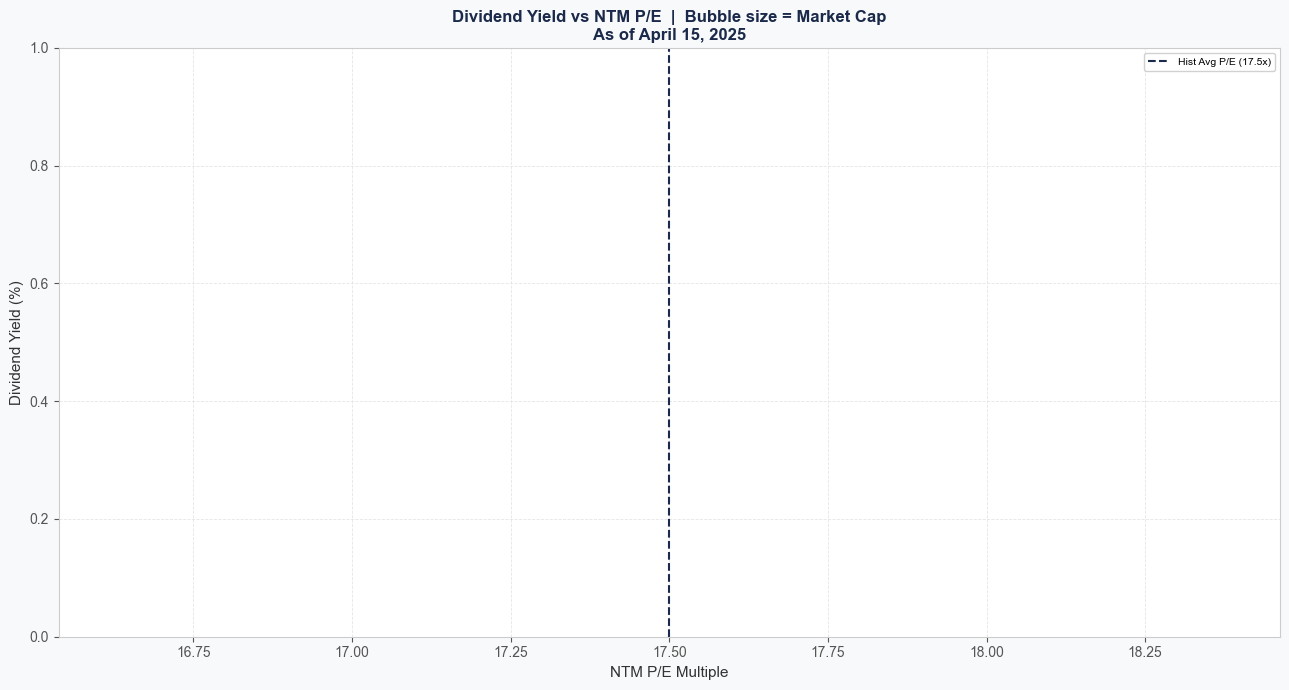

Saved: div_yield_scatter.png


In [14]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor("#F8F9FA")

plot_df = df[df["NTM P/E"].notna() & df["Dividend Yield (%)"].notna()
             & df["Market Cap ($M)"].notna()
             & (df["NTM P/E"] > 0) & (df["NTM P/E"] <= 80)].copy()

sector_list = plot_df["GICS Sector"].unique()
cmap = plt.cm.get_cmap("tab10", len(sector_list))
sector_color = {s: cmap(i) for i, s in enumerate(sector_list)}

for sector, grp in plot_df.groupby("GICS Sector"):
    sizes = (grp["Market Cap ($M)"] / plot_df["Market Cap ($M)"].max() * 600).clip(20, 600)
    ax.scatter(grp["NTM P/E"], grp["Dividend Yield (%)"],
               s=sizes, color=sector_color[sector], alpha=0.65,
               edgecolors="white", linewidths=0.6, label=sector)

# annotate a few notable names
for _, r in plot_df.nlargest(6,"Market Cap ($M)").iterrows():
    ax.annotate(r["Ticker"],
                xy=(r["NTM P/E"], r["Dividend Yield (%)"]),
                xytext=(4,4), textcoords="offset points",
                fontsize=7.5, color="#333", fontweight="bold")

ax.axvline(HIST_AVG_PE, color=NAVY, linestyle="--", linewidth=1.5,
           label=f"Hist Avg P/E ({HIST_AVG_PE}x)")
ax.set_xlabel("NTM P/E Multiple", fontsize=11)
ax.set_ylabel("Dividend Yield (%)", fontsize=11)
ax.set_title(f"Dividend Yield vs NTM P/E  |  Bubble size = Market Cap\n"
             f"As of {as_of:%B %d, %Y}", fontsize=12, fontweight="bold", color=NAVY)
ax.legend(loc="upper right", fontsize=7.5, framealpha=0.9,
          ncol=2, markerscale=0.7)

plt.tight_layout()
plt.savefig("div_yield_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: div_yield_scatter.png")

### 10e — Top 15 & Bottom 15 Companies by NTM P/E

TypeError: Column 'NTM P/E' has dtype object, cannot use method 'nlargest' with this dtype

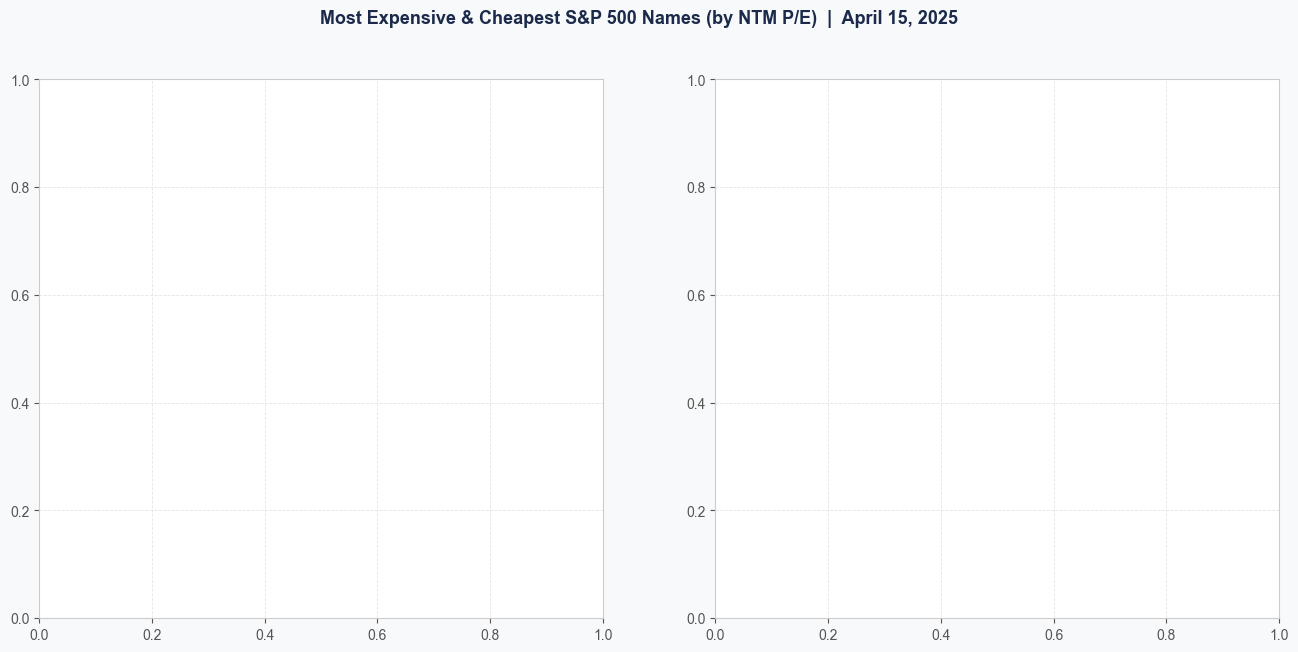

In [15]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#F8F9FA")
fig.suptitle(f"Most Expensive & Cheapest S&P 500 Names (by NTM P/E)  |  {as_of:%B %d, %Y}",
             fontsize=13, fontweight="bold", color=NAVY)

valid = df[df["NTM P/E"].notna() & (df["NTM P/E"] > 0)]

# ── most expensive ────────────────────────────────────────
top15 = valid.nlargest(15,"NTM P/E").sort_values("NTM P/E")
ax_left.barh(top15["Ticker"], top15["NTM P/E"], color=RED,
             height=0.6, edgecolor="white", linewidth=1.2)
ax_left.axvline(HIST_AVG_PE, color=NAVY, linestyle="--", linewidth=1.5,
                label=f"Hist Avg {HIST_AVG_PE}x")
for i, (_, r) in enumerate(top15.iterrows()):
    ax_left.text(r["NTM P/E"]+0.5, i, f"{r['NTM P/E']:.1f}x",
                 va="center", fontsize=8.5, fontweight="bold")
ax_left.set_title("🔴  Most Expensive (Highest NTM P/E)", color=RED, pad=8)
ax_left.set_xlabel("NTM P/E")
ax_left.legend(fontsize=8)

# ── cheapest ──────────────────────────────────────────────
bot15 = valid.nsmallest(15,"NTM P/E").sort_values("NTM P/E", ascending=False)
ax_right.barh(bot15["Ticker"], bot15["NTM P/E"], color=GREEN,
              height=0.6, edgecolor="white", linewidth=1.2)
ax_right.axvline(HIST_AVG_PE, color=NAVY, linestyle="--", linewidth=1.5,
                 label=f"Hist Avg {HIST_AVG_PE}x")
for i, (_, r) in enumerate(bot15.iterrows()):
    ax_right.text(r["NTM P/E"]+0.1, i, f"{r['NTM P/E']:.1f}x",
                  va="center", fontsize=8.5, fontweight="bold")
ax_right.set_title("🟢  Cheapest (Lowest NTM P/E, Excl. Negatives)", color=GREEN, pad=8)
ax_right.set_xlabel("NTM P/E")
ax_right.legend(fontsize=8)

plt.tight_layout()
plt.savefig("top_bottom_pe.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: top_bottom_pe.png")

## 📁 11 — Excel Export Functions

> Investment-bank-quality workbook with 4 sheets. Collapsed for readability — no need to edit.

In [ ]:
# ── Palette & style helpers ───────────────────────────────
_NAVY="1B2A4A"; _WHITE="FFFFFF"; _EVEN="F0F3F7"; _ODD="FFFFFF"
_RF="FADBD8"; _RC="922B21"; _YF="FEF9E7"; _YC="7D6608"
_GF="D5F5E3"; _GC="1E8449"; _NF="EAECEE"; _NC="717D7E"

_thin = lambda c="CCCCCC": Side(style="thin",color=c)
DATA_BORDER = Border(left=_thin(),right=_thin(),top=_thin(),bottom=_thin())

def _fill(h): return PatternFill("solid",start_color=h)
def _font(bold=False,size=9,color="000000",italic=False):
    return Font(name="Arial",bold=bold,size=size,color=color,italic=italic)
def _align(h="center",v="center",wrap=False,indent=0):
    return Alignment(horizontal=h,vertical=v,wrap_text=wrap,indent=indent)
def _row_fill(i): return _fill(_EVEN if i%2==0 else _ODD)
def _flag_styles(flag):
    return {
        "Above Avg":  (_fill(_RF),_font(bold=True,color=_RC)),
        "Within Avg": (_fill(_YF),_font(bold=True,color=_YC)),
        "Below Avg":  (_fill(_GF),_font(bold=True,color=_GC)),
    }.get(flag, (_fill(_NF),_font(bold=True,color=_NC)))
def _ntm_fill(v):
    if pd.isna(v): return _fill(_NF)
    return _fill(_RF if v>PE_HIGH_BOUND else _GF if v<PE_LOW_BOUND else _YF)

def make_labels(as_of):
    d = as_of.strftime("%B %d, %Y")
    title  = (f"S&P 500 Valuation Analysis — As of {d}  |  "
              "ECM Research  |  Bulge Bracket Bank")
    footer = (f"Source: Finviz.com Screener  |  Data as of {d}.  "
              "For internal use only. Negative/unavailable P/E excluded from averages.  "
              f"Historical avg benchmark: {HIST_AVG_PE}x (15–20x long-run range).")
    return title, footer

def _write_title(ws,txt,ncols,row=1):
    ws.merge_cells(start_row=row,start_column=1,end_row=row,end_column=ncols)
    c=ws.cell(row=row,column=1,value=txt)
    c.font=_font(bold=True,size=12,color=_WHITE)
    c.fill=_fill(_NAVY); c.alignment=_align(h="left",indent=1)
    ws.row_dimensions[row].height=24

def _write_headers(ws,hdrs,row=2):
    ws.row_dimensions[row].height=36
    hb=Border(left=_thin("4A5568"),right=_thin("4A5568"),
              top=_thin("4A5568"),bottom=_thin("4A5568"))
    for ci,h in enumerate(hdrs,1):
        c=ws.cell(row=row,column=ci,value=h)
        c.font=_font(bold=True,color=_WHITE,size=9)
        c.fill=_fill(_NAVY); c.alignment=_align(wrap=True); c.border=hb

def _write_footer(ws,txt,ncols,last_row):
    fr=last_row+2
    ws.merge_cells(start_row=fr,start_column=1,end_row=fr,end_column=ncols)
    c=ws.cell(row=fr,column=1,value=txt)
    c.font=_font(italic=True,size=7,color="888888")
    c.alignment=_align(h="left")

def _col_widths(ws,widths):
    for ci,w in enumerate(widths,1):
        ws.column_dimensions[get_column_letter(ci)].width=w

def _apply_fmt(cell,col,val):
    if col in ("Market Cap ($M)","Total Market Cap ($M)"): cell.number_format="$#,##0"
    elif col=="Share Price": cell.number_format="$#,##0.00"
    elif col in ("% of S&P 500 Index","% of Index","Dividend Yield (%)","Weighted Avg Div Yield (%)"):
        cell.number_format="0.00%"
        if pd.notna(val): cell.value=val/100
    elif any(x in col for x in ("P/E","Avg LTM P/E","Avg NTM P/E","Median LTM","Median NTM","Min NTM","Max NTM")):
        cell.number_format='0.0"x"'
    elif "Hist Avg" in col:
        cell.number_format='+0.0%;-0.0%;"-"'
        if pd.notna(val): cell.value=val/100
    elif "EPS" in col: cell.number_format="$#,##0.00"
    elif col=="No. of Companies": cell.number_format="0"

# ── Sheet builders ────────────────────────────────────────
S1_HDRS=["Ticker","Company Name","GICS Sector","GICS Sub-Industry",
         "Market Cap ($M)","% of S&P 500 Index","LTM P/E","NTM P/E",
         "Dividend Yield (%)","CY+1 EPS Est.","CQ+1 EPS Est.",
         "LTM P/E vs Hist Avg (%)","NTM P/E vs Hist Avg (%)","Valuation Flag"]
S1_COLS=["Ticker","Company Name","GICS Sector","GICS Sub-Industry",
         "Market Cap ($M)","% of S&P 500 Index","LTM P/E","NTM P/E",
         "Dividend Yield (%)","CY+1 EPS Estimate","CQ+1 EPS Estimate",
         "LTM P/E vs Hist Avg (%)","NTM P/E vs Hist Avg (%)","Valuation Flag"]

def build_master(wb,df,title_txt,footer_txt):
    ws=wb.active; ws.title="S&P500 Master Table"
    _write_title(ws,title_txt,len(S1_HDRS))
    _write_headers(ws,S1_HDRS)
    for di,(_, row) in enumerate(df.iterrows(),1):
        ri=di+2; flag=row.get("Valuation Flag","N/A"); bf=_row_fill(di)
        for ci,col in enumerate(S1_COLS,1):
            val=row.get(col); c=ws.cell(row=ri,column=ci,value=val)
            c.font=_font(size=9); c.border=DATA_BORDER
            c.alignment=_align(h="left" if ci<=2 else "center")
            if col=="NTM P/E": c.fill=_ntm_fill(row.get("NTM P/E"))
            elif col=="Valuation Flag": c.fill,c.font=_flag_styles(flag)
            else: c.fill=bf
            _apply_fmt(c,col,val)
    lr=2+len(df); ws.freeze_panes="A3"
    ws.auto_filter.ref=f"A2:{get_column_letter(len(S1_HDRS))}{lr}"
    _write_footer(ws,footer_txt,len(S1_HDRS),lr)
    _col_widths(ws,[8,32,24,36,14,11,8,8,12,12,12,18,18,13])

S2_HDRS=["Name","# Companies","% of Index","Wtd Avg LTM P/E","Wtd Avg NTM P/E",
         "Wtd Avg Div Yield (%)","Total Mkt Cap ($M)","Median LTM P/E","Median NTM P/E",
         "Min NTM P/E","Max NTM P/E","Valuation Flag"]
S2_COLS_T=[None,"No. of Companies","% of Index","Weighted Avg LTM P/E","Weighted Avg NTM P/E",
           "Weighted Avg Div Yield (%)","Total Market Cap ($M)","Median LTM P/E","Median NTM P/E",
           "Min NTM P/E","Max NTM P/E","Valuation Flag"]

def build_summary_sheet(wb,sdf,group_col,sheet_name,title_txt,footer_txt,add_chart=False):
    ws=wb.create_sheet(sheet_name)
    _write_title(ws,title_txt,len(S2_HDRS)); _write_headers(ws,S2_HDRS)
    cols=[group_col]+S2_COLS_T[1:]
    for di,(_, row) in enumerate(sdf.iterrows(),1):
        ri=di+2; flag=row.get("Valuation Flag","N/A"); bf=_row_fill(di)
        for ci,col in enumerate(cols,1):
            val=row.get(col); c=ws.cell(row=ri,column=ci,value=val)
            c.font=_font(size=9); c.border=DATA_BORDER
            c.alignment=_align(h="left" if ci==1 else "center")
            if col=="Weighted Avg NTM P/E": c.fill=_ntm_fill(row.get("Weighted Avg NTM P/E"))
            elif col=="Valuation Flag": c.fill,c.font=_flag_styles(flag)
            else: c.fill=bf
            _apply_fmt(c,col,val)
    lr=2+len(sdf); ws.freeze_panes="A3"
    ws.auto_filter.ref=f"A2:{get_column_letter(len(S2_HDRS))}{lr}"
    _write_footer(ws,footer_txt,len(S2_HDRS),lr)
    _col_widths(ws,[36,12,10,14,14,16,18,13,13,11,11,13])
    if add_chart: _add_chart(ws,sdf,group_col,lr)

def _add_chart(ws,sdf,group_col,lr):
    cr=lr+4
    ws.cell(row=cr-1,column=1,
            value="Weighted Avg NTM P/E by Sector vs. Historical Average"
            ).font=_font(bold=True,size=11,color=_NAVY)
    ws.cell(row=cr,column=1,value="Sector").font=_font(bold=True)
    ws.cell(row=cr,column=2,value="NTM P/E").font=_font(bold=True)
    ws.cell(row=cr,column=3,value=f"Hist Avg ({HIST_AVG_PE}x)").font=_font(bold=True)
    for i,(_, row) in enumerate(sdf.iterrows(),1):
        rr=cr+i; ntm=row.get("Weighted Avg NTM P/E")
        ws.cell(row=rr,column=1,value=row.get(group_col,row.iloc[0]))
        ws.cell(row=rr,column=2,value=round(ntm,2) if pd.notna(ntm) else 0)
        ws.cell(row=rr,column=3,value=HIST_AVG_PE)
    n=len(sdf); chart=BarChart()
    chart.type="col"; chart.grouping="clustered"
    chart.title="Weighted Avg NTM P/E by GICS Sector vs. Historical Average"
    chart.y_axis.title="NTM P/E (x)"; chart.x_axis.title="GICS Sector"
    chart.style=10; chart.width=30; chart.height=16
    chart.add_data(Reference(ws,min_col=2,max_col=3,min_row=cr,max_row=cr+n),titles_from_data=True)
    chart.set_categories(Reference(ws,min_col=1,min_row=cr+1,max_row=cr+n))
    chart.series[0].graphicalProperties.solidFill="2E4057"
    chart.series[1].graphicalProperties.solidFill="E74C3C"
    ws.add_chart(chart,f"A{cr+2}")

def _section_hdr(ws,title,color,ncols,row):
    ws.merge_cells(start_row=row,start_column=1,end_row=row,end_column=ncols)
    c=ws.cell(row=row,column=1,value=title)
    c.font=_font(bold=True,color=_WHITE,size=10)
    c.fill=_fill(color); c.alignment=_align(); ws.row_dimensions[row].height=22

def _subtable(ws,title,color,hdrs,rows,start_row):
    _section_hdr(ws,title,color,len(hdrs),start_row)
    hr=start_row+1; ws.row_dimensions[hr].height=28
    hb=Border(left=_thin("4A5568"),right=_thin("4A5568"),
              top=_thin("4A5568"),bottom=_thin("4A5568"))
    for ci,h in enumerate(hdrs,1):
        c=ws.cell(row=hr,column=ci,value=h)
        c.font=_font(bold=True,color=_WHITE,size=9)
        c.fill=_fill(_NAVY); c.alignment=_align(wrap=True); c.border=hb
    for ri_off,rd in enumerate(rows):
        ri=hr+1+ri_off
        for ci,val in enumerate(rd,1):
            c=ws.cell(row=ri,column=ci,value=val)
            c.font=_font(size=9); c.border=DATA_BORDER
            c.alignment=_align(h="left" if ci==1 else "center")
            c.fill=_row_fill(ri_off+1)
    return hr+1+len(rows)

def _co_rows(subset):
    out=[]
    for _,r in subset.iterrows():
        out.append([r.get("Ticker",""),r.get("Company Name",""),r.get("GICS Sector",""),
                    f"{r['NTM P/E']:.1f}x",
                    f"{r['LTM P/E']:.1f}x" if pd.notna(r.get("LTM P/E")) else "N/A",
                    f"{r['Dividend Yield (%)']:.2f}%" if pd.notna(r.get("Dividend Yield (%)")) else "—",
                    f"${r['Market Cap ($M)']:,.0f}M" if pd.notna(r.get("Market Cap ($M)")) else "N/A"])
    return out

def _sec_rows(subset):
    out=[]
    for _,r in subset.iterrows():
        wntm=r.get("Weighted Avg NTM P/E"); wltm=r.get("Weighted Avg LTM P/E")
        mc=r.get("Total Market Cap ($M)")
        out.append([r.iloc[0],
                    f"{wntm:.1f}x" if pd.notna(wntm) else "N/A",
                    f"{wltm:.1f}x" if pd.notna(wltm) else "N/A",
                    int(r.get("No. of Companies",0)),
                    f"${mc:,.0f}M" if pd.notna(mc) else "N/A"])
    return out

CO_H =["Ticker","Company","GICS Sector","NTM P/E","LTM P/E","Div Yield","Mkt Cap ($M)"]
SEC_H=["Sub-Industry / Sector","Wtd Avg NTM P/E","Wtd Avg LTM P/E","# Co.","Total Mkt Cap"]

def build_extremes(wb,df,sub_df,title_txt,footer_txt):
    ws=wb.create_sheet("Extremes Dashboard")
    _write_title(ws,title_txt,7)
    valid=df[df["NTM P/E"].notna()&(df["NTM P/E"]>0)]
    vsub=sub_df[sub_df["Weighted Avg NTM P/E"].notna()]
    cur=3
    cur=_subtable(ws,"🔴  TOP 25 MOST EXPENSIVE — By NTM P/E  (Potential Over-Enthusiasm)",
                  "C0392B",CO_H,_co_rows(valid.nlargest(25,"NTM P/E")),cur)+2
    cur=_subtable(ws,"🟢  TOP 25 CHEAPEST — By NTM P/E, Excl. Negatives  (Potential Over-Selling)",
                  "1E8449",CO_H,_co_rows(valid.nsmallest(25,"NTM P/E")),cur)+2
    cur=_subtable(ws,"🔴  TOP 25 MOST EXPENSIVE SUB-SECTORS — Wtd Avg NTM P/E",
                  "7B241C",SEC_H,_sec_rows(vsub.head(25)),cur)+2
    cur=_subtable(ws,"🟢  TOP 25 CHEAPEST SUB-SECTORS — Wtd Avg NTM P/E",
                  "1A5276",SEC_H,_sec_rows(vsub.nsmallest(25,"Weighted Avg NTM P/E")),cur)+2
    _write_footer(ws,footer_txt,7,cur)
    _col_widths(ws,[8,32,26,10,10,12,14])

def build_workbook(df,sub_df,sec_df,as_of):
    title_txt,footer_txt=make_labels(as_of)
    wb=Workbook()
    build_master(wb,df,title_txt,footer_txt)
    build_summary_sheet(wb,sub_df,"GICS Sub-Industry","Sub-Sector Summary",title_txt,footer_txt)
    build_summary_sheet(wb,sec_df,"GICS Sector","Sector Summary",title_txt,footer_txt,add_chart=True)
    build_extremes(wb,df,sub_df,title_txt,footer_txt)
    return wb

print("✅  Excel builder functions defined")

## 💾 12 — Build & Save Excel Workbook

In [ ]:
# Resolve output path  (auto-dated if OUTPUT_XLSX is None)
if OUTPUT_XLSX:
    out_path = Path(OUTPUT_XLSX)
else:
    out_path = Path(f"SP500_Valuation_Analysis_{as_of:%Y-%m-%d}.xlsx")

out_path.parent.mkdir(parents=True, exist_ok=True)

print(f"Building workbook for {as_of:%B %d, %Y} …")
wb = build_workbook(df, sub_df, sec_df, as_of)
wb.save(str(out_path))

print(f"\n✅  Saved → {out_path.resolve()}")
print(f"   Sheet 1: S&P500 Master Table   ({len(df)} companies)")
print(f"   Sheet 2: Sub-Sector Summary    ({len(sub_df)} sub-industries)")
print(f"   Sheet 3: Sector Summary        ({len(sec_df)} sectors + bar chart)")
print(f"   Sheet 4: Extremes Dashboard    (top/bottom 25 companies & sub-sectors)")

## 📋 13 — Final Console Summary

In [ ]:
flags    = df["Valuation Flag"].value_counts()
total    = len(df)
total_mc = df["Market Cap ($M)"].sum(skipna=True)

def wt_pe(pe_col):
    v=df[df[pe_col].notna()&(df[pe_col]>0)&df["Market Cap ($M)"].notna()]
    if v.empty: return float("nan")
    return (v[pe_col]*v["Market Cap ($M)"]).sum()/v["Market Cap ($M)"].sum()

sp_ntm=wt_pe("NTM P/E"); sp_ltm=wt_pe("LTM P/E")
vsub=sub_df[sub_df["Weighted Avg NTM P/E"].notna()]

print("\n" + "═"*68)
print(f"   S&P 500 VALUATION ANALYSIS  |  {as_of:%B %d, %Y}  |  ECM Research")
print("═"*68)
print(f"\n  DATA COVERAGE:")
print(f"    Companies loaded            : {total}")
print(f"    Missing NTM P/E             : {df['NTM P/E'].isna().sum()}  ({df['NTM P/E'].isna().sum()/total*100:.1f}%)")
print(f"    Missing LTM P/E             : {df['LTM P/E'].isna().sum()}  ({df['LTM P/E'].isna().sum()/total*100:.1f}%)")
print(f"\n  VALUATION FLAGS  (<{PE_LOW_BOUND}x=Below  |  {PE_LOW_BOUND}–{PE_HIGH_BOUND}x=Within  |  >{PE_HIGH_BOUND}x=Above):")
for f in ("Above Avg","Within Avg","Below Avg","N/A"):
    n=int(flags.get(f,0))
    bar="█"*int(n/max(total,1)*38)
    print(f"    {f:<14}  {n:>3}  ({n/max(total,1)*100:5.1f}%)  {bar}")
print(f"\n  S&P 500 INDEX  (Market-Cap Weighted):")
print(f"    Wtd Avg NTM P/E : {sp_ntm:.1f}x  (vs {HIST_AVG_PE}x hist → {(sp_ntm/HIST_AVG_PE-1)*100:+.1f}%)")
print(f"    Wtd Avg LTM P/E : {sp_ltm:.1f}x  (vs {HIST_AVG_PE}x hist → {(sp_ltm/HIST_AVG_PE-1)*100:+.1f}%)")
print(f"    Total Mkt Cap   : ${total_mc/1e6:,.2f}T")
print(f"\n  TOP 5 MOST EXPENSIVE SUB-SECTORS:")
for i,(_, r) in enumerate(vsub.head(5).iterrows(),1):
    print(f"    {i}. {r.iloc[0]:<44} {r['Weighted Avg NTM P/E']:.1f}x")
print(f"\n  TOP 5 CHEAPEST SUB-SECTORS:")
for i,(_, r) in enumerate(vsub.nsmallest(5,"Weighted Avg NTM P/E").iterrows(),1):
    print(f"    {i}. {r.iloc[0]:<44} {r['Weighted Avg NTM P/E']:.1f}x")
print("\n" + "═"*68)
print(f"  Excel workbook saved → {out_path.resolve()}")
print("═"*68)